In [1]:

import numpy as np 
import pandas as pd 
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression
import xgboost
from sklearn.feature_selection import mutual_info_regression
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import Pool, CatBoostRegressor, cv
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

In [2]:
# !pip install xgboost

In [3]:
data = pd.read_csv('E-commerce.csv', encoding='latin')
data.head()

,Order_Date,Time,Aging,Customer_Id,Gender,Device_Type,Customer_Login_type,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Order_Priority,Payment_method
0,2018-01-02,10:56:33,8.0,37077,Female,Web,Member,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,Medium,credit_card
1,2018-07-24,20:41:37,2.0,59173,Female,Web,Member,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,Medium,credit_card
2,2018-11-08,08:38:49,8.0,41066,Female,Web,Member,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,Critical,credit_card
3,2018-04-18,19:28:06,7.0,50741,Female,Web,Member,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,High,credit_card
4,2018-08-13,21:18:39,9.0,53639,Female,Web,Member,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,Critical,credit_card


In [4]:
data = data[['Product_Category', 'Product', 'Sales',
       'Quantity', 'Discount', 'Profit', 'Shipping_Cost']]

# data = data[['Sales','Quantity', 'Discount', 'Profit', 'Shipping_Cost']]

In [5]:
# from sklearn.preprocessing import LabelEncoder

# # Assuming df is your DataFrame
# label_encoder = LabelEncoder()

# data['Product_Category_Label'] = label_encoder.fit_transform(data['Product_Category'])
# data['Product_Label'] = label_encoder.fit_transform(data['Product'])


In [6]:
from sklearn.preprocessing import LabelEncoder
import joblib

# Assuming df is your DataFrame and 'Product_Category' is the column you want to encode
label_encoder_product_category = LabelEncoder()
data['Product_Category_Label'] = label_encoder_product_category.fit_transform(data['Product_Category'])

# Save the label encoder to a file
joblib.dump(label_encoder_product_category, 'label_encoder_product_category.pkl')


# Assuming df is your DataFrame and 'Product_Category' is the column you want to encode
label_encoder_product_type = LabelEncoder()
data['Product_type_Label'] = label_encoder_product_type.fit_transform(data['Product'])

# Save the label encoder to a file
joblib.dump(label_encoder_product_type, 'label_encoder_product_type.pkl')



['label_encoder_product_type.pkl']

In [7]:
data.head()

,Product_Category,Product,Sales,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
0,Auto & Accessories,Car Media Players,140.0,1.0,0.3,46.0,4.6,0,7
1,Auto & Accessories,Car Speakers,211.0,1.0,0.3,112.0,11.2,0,10
2,Auto & Accessories,Car Body Covers,117.0,5.0,0.1,31.2,3.1,0,5
3,Auto & Accessories,Car & Bike Care,118.0,1.0,0.3,26.2,2.6,0,4
4,Auto & Accessories,Tyre,250.0,1.0,0.3,160.0,16.0,0,39


In [8]:
data['Product_Category_Label'].unique()

array([0, 2, 1, 3])

In [9]:
label_mapping_dict = dict(zip(label_encoder_product_category.classes_, label_encoder_product_category.transform(label_encoder_product_category.classes_)))
label_mapping_dict

{'Auto & Accessories': 0, 'Electronic': 1, 'Fashion': 2, 'Home & Furniture': 3}

In [10]:
# label_mapping_dict = dict(zip(label_encoder_product_type.classes_, label_encoder_product_type.transform(label_encoder_product_type.classes_)))
# label_mapping_dict

label_mapping_dict = {encoded_value: label for label, encoded_value in zip(label_encoder_product_type.classes_, label_encoder_product_type.transform(label_encoder_product_type.classes_))}
label_mapping_dict

{0: 'Apple Laptop',
 1: 'Bed Sheets',
 2: 'Beds',
 3: 'Bike Tyres',
 4: 'Car & Bike Care',
 5: 'Car Body Covers',
 6: 'Car Mat',
 7: 'Car Media Players',
 8: 'Car Pillow & Neck Rest',
 9: 'Car Seat Covers',
 10: 'Car Speakers',
 11: 'Casula Shoes',
 12: 'Curtains',
 13: 'Dinner Crockery',
 14: 'Dinning Tables',
 15: 'Fans',
 16: 'Formal Shoes',
 17: 'Fossil Watch',
 18: 'Iron',
 19: 'Jeans',
 20: 'Keyboard',
 21: 'LCD',
 22: 'LED',
 23: 'Mixer/Juicer',
 24: 'Mouse',
 25: 'Running Shoes',
 26: 'Samsung Mobile',
 27: 'Shirts',
 28: 'Shoe Rack',
 29: 'Sneakers',
 30: 'Sofa Covers',
 31: 'Sofas',
 32: 'Speakers',
 33: 'Sports Wear',
 34: 'Suits',
 35: 'T - Shirts',
 36: 'Tablet',
 37: 'Titak watch',
 38: 'Towels',
 39: 'Tyre',
 40: 'Umbrellas',
 41: 'Watch'}

In [11]:
# Assuming df is your DataFrame
data = pd.get_dummies(data, columns=['Product_Category', 'Product'], drop_first=True)


In [12]:
# prod.cat , pro.name,quanti
data.columns

Index(['Sales', 'Quantity', 'Discount', 'Profit', 'Shipping_Cost',
       'Product_Category_Label', 'Product_type_Label',
       'Product_Category_Electronic', 'Product_Category_Fashion',
       'Product_Category_Home & Furniture', 'Product_Bed Sheets',
       'Product_Beds', 'Product_Bike Tyres', 'Product_Car & Bike Care',
       'Product_Car Body Covers', 'Product_Car Mat',
       'Product_Car Media Players', 'Product_Car Pillow & Neck Rest',
       'Product_Car Seat Covers', 'Product_Car Speakers',
       'Product_Casula Shoes', 'Product_Curtains', 'Product_Dinner Crockery',
       'Product_Dinning Tables', 'Product_Fans', 'Product_Formal Shoes',
       'Product_Fossil Watch', 'Product_Iron', 'Product_Jeans',
       'Product_Keyboard', 'Product_LCD', 'Product_LED',
       'Product_Mixer/Juicer', 'Product_Mouse', 'Product_Running Shoes',
       'Product_Samsung Mobile', 'Product_Shirts', 'Product_Shoe Rack',
       'Product_Sneakers', 'Product_Sofa Covers', 'Product_Sofas',
       'P

In [13]:
data.shape

(51290, 51)

**Handling NaN values**

In [14]:
# df.isnull().any()
# df.isnull().sum()

#isnull & isna are the same in python/pandas
data.isna().sum()

Sales                                1
Quantity                             2
Discount                             1
Profit                               0
Shipping_Cost                        1
Product_Category_Label               0
Product_type_Label                   0
Product_Category_Electronic          0
Product_Category_Fashion             0
Product_Category_Home & Furniture    0
Product_Bed Sheets                   0
Product_Beds                         0
Product_Bike Tyres                   0
Product_Car & Bike Care              0
Product_Car Body Covers              0
Product_Car Mat                      0
Product_Car Media Players            0
Product_Car Pillow & Neck Rest       0
Product_Car Seat Covers              0
Product_Car Speakers                 0
Product_Casula Shoes                 0
Product_Curtains                     0
Product_Dinner Crockery              0
Product_Dinning Tables               0
Product_Fans                         0
Product_Formal Shoes     

In [15]:
data = data.dropna()

In [16]:
data.shape

(51285, 51)

In [17]:
# df.isnull().sum()


**Unique values in df**

In [18]:
#Unique values in the dataframe
data.nunique()

Sales                                 39
Quantity                               5
Discount                               5
Profit                               391
Shipping_Cost                        153
Product_Category_Label                 4
Product_type_Label                    42
Product_Category_Electronic            2
Product_Category_Fashion               2
Product_Category_Home & Furniture      2
Product_Bed Sheets                     2
Product_Beds                           2
Product_Bike Tyres                     2
Product_Car & Bike Care                2
Product_Car Body Covers                2
Product_Car Mat                        2
Product_Car Media Players              2
Product_Car Pillow & Neck Rest         2
Product_Car Seat Covers                2
Product_Car Speakers                   2
Product_Casula Shoes                   2
Product_Curtains                       2
Product_Dinner Crockery                2
Product_Dinning Tables                 2
Product_Fans    

In [19]:
# print(data.describe())
# print(data.info())
data.describe()

,Sales,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
count,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000,51285.000000
mean,152.340548,2.502935,0.303833,70.404395,7.041427,1.955874,21.894999
std,66.492851,1.511834,0.131024,48.728944,4.871768,0.967847,11.832106
min,33.000000,1.000000,0.100000,0.500000,0.100000,0.000000,0.000000
25%,85.000000,1.000000,0.200000,24.900000,2.500000,2.000000,12.000000
50%,133.000000,2.000000,0.300000,59.900000,6.000000,2.000000,25.000000
75%,218.000000,4.000000,0.400000,118.400000,11.800000,3.000000,33.000000
max,250.000000,5.000000,0.500000,167.500000,16.800000,3.000000,41.000000


In [20]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 51285 entries, 0 to 51289
Data columns (total 51 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Sales                              51285 non-null  float64
 1   Quantity                           51285 non-null  float64
 2   Discount                           51285 non-null  float64
 3   Profit                             51285 non-null  float64
 4   Shipping_Cost                      51285 non-null  float64
 5   Product_Category_Label             51285 non-null  int32  
 6   Product_type_Label                 51285 non-null  int32  
 7   Product_Category_Electronic        51285 non-null  bool   
 8   Product_Category_Fashion           51285 non-null  bool   
 9   Product_Category_Home & Furniture  51285 non-null  bool   
 10  Product_Bed Sheets                 51285 non-null  bool   
 11  Product_Beds                       51285 non-null  bool   


In [21]:
data = data.dropna()

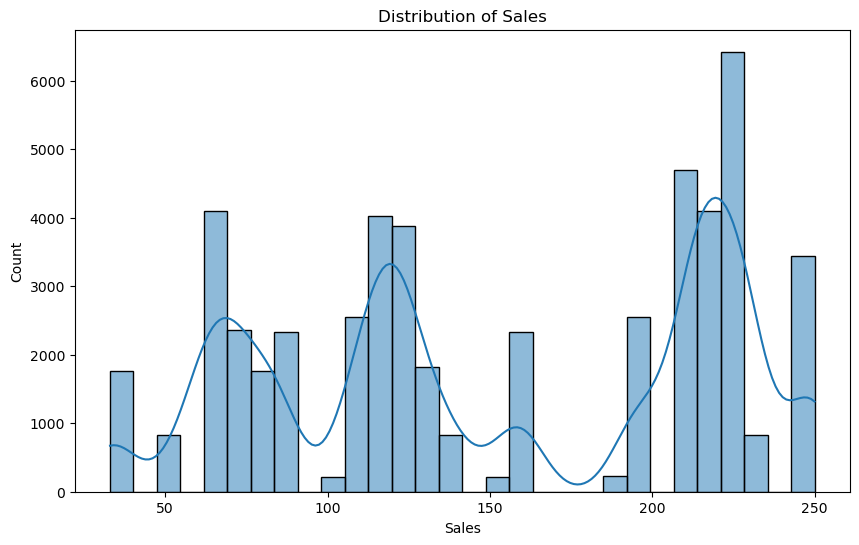

In [22]:
# Visualize the target variable (Sales)
plt.figure(figsize=(10, 6))
sns.histplot(data['Sales'], bins=30, kde=True)
plt.title('Distribution of Sales')
plt.show()

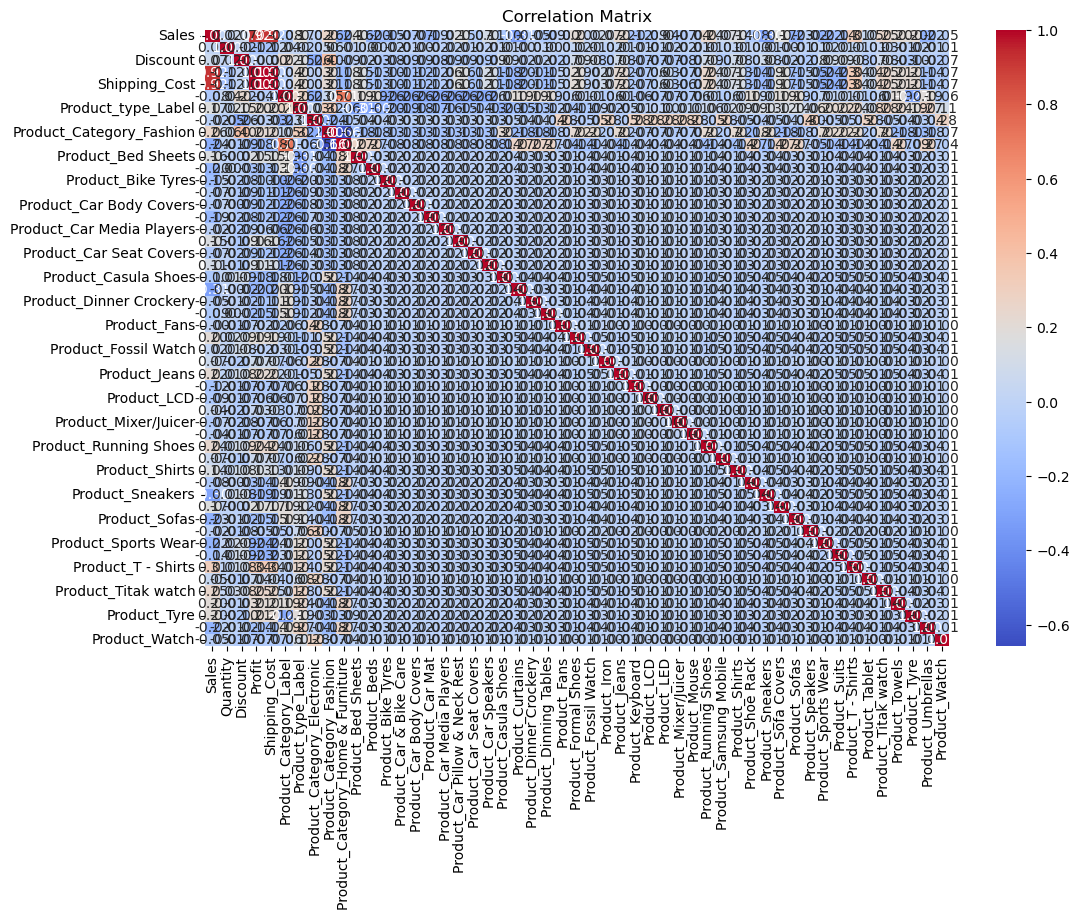

In [23]:

# Correlation matrix
correlation_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

In [24]:
# Assuming X and y are your features and target variable
X = data[['Quantity', 'Discount', 'Profit', 'Shipping_Cost', 'Product_Category_Label', 'Product_type_Label']]
y = data['Sales']

# Continue with the model training, splitting, and training steps from the previous code


In [25]:
# split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=0)


In [26]:
X_train

,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
35540,2.0,0.3,35.0,3.5,3,40
27046,1.0,0.3,125.2,12.5,3,38
34799,2.0,0.4,34.1,3.4,3,28
44205,4.0,0.1,135.0,13.5,2,25
40806,5.0,0.5,79.8,8.0,2,16
...,...,...,...,...,...,...
21248,5.0,0.4,94.4,9.4,2,19
45896,3.0,0.5,12.7,1.3,2,34
42618,4.0,0.3,21.3,2.1,2,33
43572,5.0,0.4,118.4,11.8,2,35


In [27]:
X

,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label
0,1.0,0.3,46.0,4.6,0,7
1,1.0,0.3,112.0,11.2,0,10
2,5.0,0.1,31.2,3.1,0,5
3,1.0,0.3,26.2,2.6,0,4
4,1.0,0.3,160.0,16.0,0,39
...,...,...,...,...,...,...
51285,4.0,0.3,19.2,1.9,3,28
51286,5.0,0.2,14.0,1.4,3,40
51287,1.0,0.3,39.7,4.0,3,13
51288,1.0,0.2,131.7,13.2,3,30


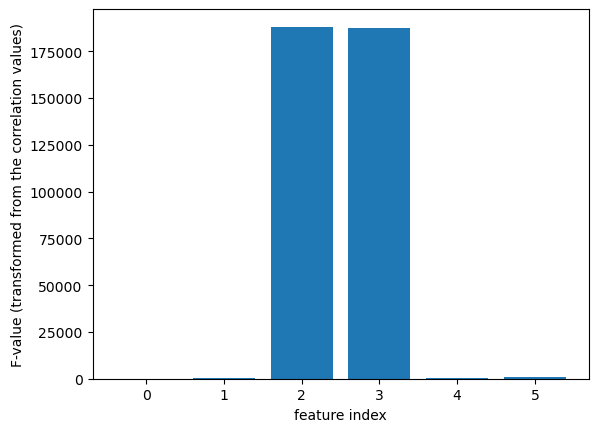

In [28]:
# feature selection
f_selector = SelectKBest(score_func=f_regression, k='all')
# learn relationship from training data
f_selector.fit(X_train, y_train)
# transform train input data
X_train_fs = f_selector.transform(X_train)
# transform test input data
X_test_fs = f_selector.transform(X_test)
# Plot the scores for the features
plt.bar([i for i in range(len(f_selector.scores_))], f_selector.scores_)
plt.xlabel("feature index")
plt.ylabel("F-value (transformed from the correlation values)")
plt.show()

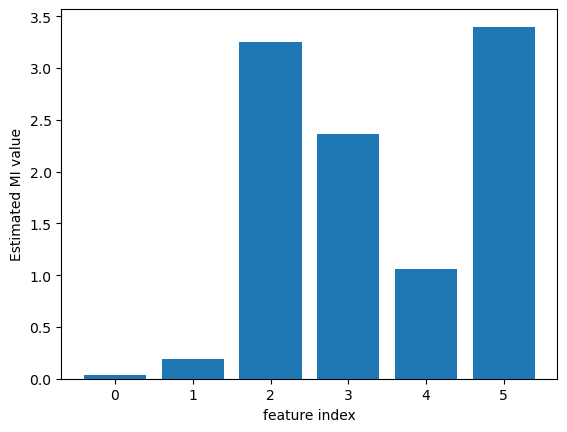

In [29]:
# feature selection
f_selector = SelectKBest(score_func=mutual_info_regression, k='all')
# learn relationship from training data
f_selector.fit(X_train, y_train)
# transform train input data
X_train_fs = f_selector.transform(X_train)
# transform test input data
X_test_fs = f_selector.transform(X_test)
# Plot the scores for the features
plt.bar([i for i in range(len(f_selector.scores_))], f_selector.scores_)
plt.xlabel("feature index")
plt.ylabel("Estimated MI value")
plt.show()

In [30]:


X=data.drop(columns=['Sales'])

X=X.fillna(-1) 
print(X.columns)
# categorical_features_indices =[0,1]
y=data['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42)

X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.2, 
                                                    random_state=52)

Index(['Quantity', 'Discount', 'Profit', 'Shipping_Cost',
       'Product_Category_Label', 'Product_type_Label',
       'Product_Category_Electronic', 'Product_Category_Fashion',
       'Product_Category_Home & Furniture', 'Product_Bed Sheets',
       'Product_Beds', 'Product_Bike Tyres', 'Product_Car & Bike Care',
       'Product_Car Body Covers', 'Product_Car Mat',
       'Product_Car Media Players', 'Product_Car Pillow & Neck Rest',
       'Product_Car Seat Covers', 'Product_Car Speakers',
       'Product_Casula Shoes', 'Product_Curtains', 'Product_Dinner Crockery',
       'Product_Dinning Tables', 'Product_Fans', 'Product_Formal Shoes',
       'Product_Fossil Watch', 'Product_Iron', 'Product_Jeans',
       'Product_Keyboard', 'Product_LCD', 'Product_LED',
       'Product_Mixer/Juicer', 'Product_Mouse', 'Product_Running Shoes',
       'Product_Samsung Mobile', 'Product_Shirts', 'Product_Shoe Rack',
       'Product_Sneakers', 'Product_Sofa Covers', 'Product_Sofas',
       'Product_Sp

In [31]:
# !pip install catboost

In [32]:
def perform_model(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model = CatBoostRegressor(
        random_seed = 400,
        loss_function = 'RMSE',
        iterations=400,
    )
    
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        verbose=False
    )
    
    print("RMSE on training data: "+ model.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model.score(X_test, y_test).astype(str))
    
    return model
model=perform_model(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 0.9999855362206053
RMSE on test data: 0.9999843895864571


In [33]:
from sklearn.ensemble import RandomForestRegressor
def perform_model_rr(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model = RandomForestRegressor()
    
    model.fit(X_train, y_train)
    
    print("RMSE on training data: "+ model.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model.score(X_test, y_test).astype(str))
    
    return model
model=perform_model_rr(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 0.9999999043987332
RMSE on test data: 0.99999969292969


In [34]:
def perform_model_lr(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model_lr = LinearRegression()
    
    model_lr.fit(
        X_train, y_train)
    
    print("RMSE on training data: "+ model_lr.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model_lr.score(X_test, y_test).astype(str))
    
    return model_lr
model_lr = perform_model_lr(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 1.0
RMSE on test data: 1.0


In [35]:
model_lr

LinearRegression()

In [36]:
def perform_model_xg(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model = xgboost.XGBRegressor()
    
    model.fit(
        X_train, y_train)
    
    print("RMSE on training data: "+ model.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model.score(X_test, y_test).astype(str))
    
    return model
model=perform_model_xg(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 0.9999941398231683
RMSE on test data: 0.9999935233467554


In [37]:
def perform_model_dr(X_train, y_train,X_valid, y_valid,X_test, y_test):
    model = DecisionTreeRegressor()
    
    model.fit(
        X_train, y_train)
    
    print("RMSE on training data: "+ model.score(X_train, y_train).astype(str))
    print("RMSE on test data: "+ model.score(X_test, y_test).astype(str))
    
    return model
model=perform_model_dr(X_train, y_train,X_valid, y_valid,X_test, y_test)

RMSE on training data: 1.0
RMSE on test data: 1.0


In [38]:
import pickle
pickle.dump(model_lr, open('lr_model_new.pkl', 'wb')) 

In [39]:
X_train

,Quantity,Discount,Profit,Shipping_Cost,Product_Category_Label,Product_type_Label,Product_Category_Electronic,Product_Category_Fashion,Product_Category_Home & Furniture,Product_Bed Sheets,...,Product_Speakers,Product_Sports Wear,Product_Suits,Product_T - Shirts,Product_Tablet,Product_Titak watch,Product_Towels,Product_Tyre,Product_Umbrellas,Product_Watch
15879,1.0,0.2,107.5,10.8,0,39,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
19565,3.0,0.2,42.2,4.2,1,32,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False
14217,5.0,0.5,1.8,0.2,2,34,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
9742,5.0,0.5,11.5,1.2,2,11,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
24599,1.0,0.3,141.2,14.1,2,37,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21907,5.0,0.5,67.0,6.7,2,27,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
46671,1.0,0.2,17.0,1.7,3,12,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
41277,5.0,0.3,23.7,2.4,2,11,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
34967,3.0,0.1,26.0,2.6,3,2,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


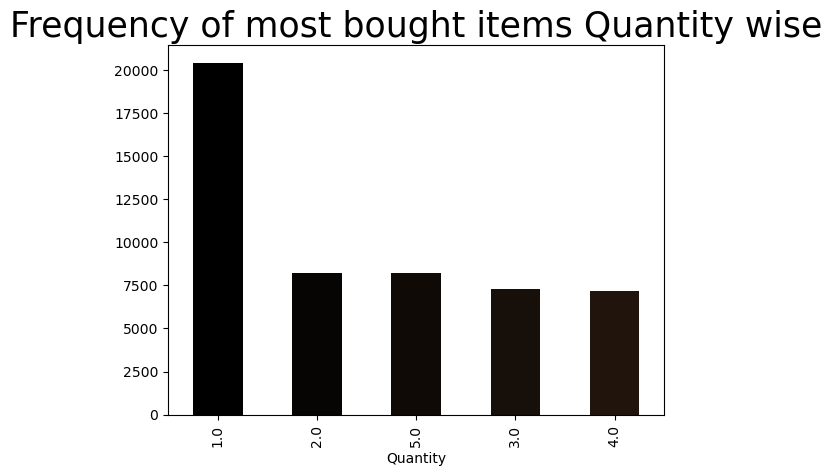

In [40]:
# plt.rcParams['figure.figsize'] = (18, 7) #the figure size. The only important is the (18, 7) as it's different than the default figure size
color = plt.cm.copper(np.linspace(0, 1, 40)) #importance: color 
data['Quantity'].value_counts().head(40).plot.bar(color = color)
plt.title('Frequency of most bought items Quantity wise', fontsize=25)
plt.show()

In [41]:
# Convert 'Sales' column to numeric with coercion
data['Sales'] = pd.to_numeric(data['Sales'], errors='coerce')

# Check unique values
print(data['Sales'].unique())

# Check value counts for the top 5 values
print(data['Sales'].value_counts().head(5))


[140. 211. 117. 118. 250.  72.  54. 114. 231. 196. 218. 109.  85. 122.
 224. 213.  62. 228. 159. 248. 220. 104. 149. 222. 199. 111.  33.  83.
 192.  65. 130. 216.  34.  67.  78. 119. 124.  70. 133.]
Sales
228.0    3872
211.0    2366
248.0    2332
159.0    2332
196.0    2332
Name: count, dtype: int64


In [42]:
import pickle
import numpy as np
pickled_model = pickle.load(open('lr_model_new2.pkl', 'rb'))
prediction = pickled_model.predict(np.array([[20,3,3.0,0.3,46.0,4.6]]))
prediction_str = f'The predicted value is: {prediction[0]:.2f}'
prediction_str




'The predicted value is: 99.33'

In [ ]:
run app.py


 * Serving Flask app 'app'
 * Debug mode: on


 * Running on http://127.0.0.1:5003
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)
